# Taller: Creación y Visualización de KPIs

## Objetivos de Aprendizaje

* **De Conocimientos:** Evidenciar cómo un Sistema de Información Gerencial (MIS) sintetiza los datos atómicos y transaccionales de un *Transaction Processing System* (TPS) en un repositorio común para generar reportes estructurados que apoyen la toma de decisiones medibles (KPIs).
* **De Destrezas:** Aplicar el enfoque de sistemas para resolver un problema de TI organizacional, mapeando el flujo desde los *Data Items* elementales hasta el *Knowledge* estratégico.
* **De Valores y Actitudes:** Experimentar el trabajo en equipo a través del codiseño de una solución de software empresarial y la presentación de argumentos técnicos efectivos.

## Introducción (Enlace Arquitectónico)

Recordemos que los **Sistemas de Procesamiento de Transacciones (TPS)** se encargan de monitorear, recolectar, almacenar y procesar los datos de las operaciones básicas diarias de la organización (datos en tiempo real, de alto volumen y nivel atómico).

Por otro lado, los **Sistemas de Información Gerencial (MIS)** acceden a estos repositorios comunes de datos transaccionales para resumirlos, procesarlos y presentar reportes estructurados (como indicadores clave de rendimiento o **KPIs**) orientados a mandos medios y gerenciales. Nuestro objetivo de hoy es construir la capa del MIS que consume los datos del TPS que ustedes ya desarrollaron.

## 1: Construir Conocimiento desde los Datos

En esta fase inicial, cada equipo de trabajo debe formalizar el ciclo de vida de la información que va a visualizar, e identificar **3 KPIs** de su proyecto, para construir en esta actividad. Para los **3 KPIs** seleccionados, completen la siguiente matriz conceptual en su informe:

1. **Data Items (Datos Crudos):** Describan los hechos elementales almacenados en su TPS sin organizar (ej. marcas de tiempo, IDs de transacciones, valores numéricos crudos).
2. **Information (Información Organizada):** Expliquen cómo la agregación o procesamiento matemático de esos datos les asigna un significado y un valor contextual para el negocio.
3. **Knowledge (Conocimiento Aplicado):** Describan la lógica o experiencia acumulada que determina qué decisión operativa o táctica se tomará según el comportamiento del KPI (ej. si el indicador supera un umbral de alerta, qué proceso se dispara).

> **Aviso de Calidad de Datos:** Al diseñar su flujo, recuerden el principio **GIGO (*Garbage In, Garbage Out*)**. Si los datos capturados originalmente por su TPS contienen inconsistencias o faltas de integridad, el reporte generado por el MIS carecerá de confiabilidad y validez para la toma de decisiones.

## KPI 1 - Total de ingresos
### Datos crudos
- idVenta
- total
- cantidad
- fecha
### Informacion
Los datos de cada transaccion son procesados y sumados para calcular el ingreso total generado por la tienda durante un periodo.
### Conocimiento aplicado
Si el total de ingresos disminuye, significativamente, la gerencia debe aplicar promociones, descuentos o campañas de marketing para aumentar las ventas.

---

## KPI 2 - Producto mas vendido
- idProducto
- cantidad
- idVenta
### Informacion
Los ventas se agrupan por productos para identificar cualers tienen mayor demanda y frecuencia de compra.
### Conocimientos
Si un producto presenta una alta demanda la empresa debe aumentar el stock disponible.

---

## KPI 3 - Categoria mas vendida
### Datos crudos
- categoria
- id producto
- cantidad
### Informacion
Los productos vendidos se clasifican por categorias para determinar cuales generan mas ventas.
### Conocimiento
Si una categoria domina las ventas, la gerencia debe enfocar inversiones y estrategias comericales en esa linea productos.

# 2. Mapeo de Atributos y Boceto de Interfaz

## 2.1 Mapeo en el Esquema de Base de Datos

El sistema TPS de la tienda utiliza tres archivos CSV como repositorio de datos:

### Tabla: productos.csv

| Atributo | Descripción |
|---|---|
| id | Identificador único del producto |
| nombre | Nombre del producto |
| precio | Precio unitario |
| stock | Cantidad disponible |
| categoria | Categoría del producto |

---

### Tabla: usuarios.csv

| Atributo | Descripción |
|---|---|
| id | Identificador único del usuario |
| nombre | Nombre del cliente |
| correo | Correo electrónico |

---

### Tabla: ventas.csv

| Atributo | Descripción |
|---|---|
| idVenta | Identificador de la venta |
| idUsuario | Usuario que realizó la compra |
| idProducto | Producto vendido |
| cantidad | Cantidad vendida |
| total | Valor total de la venta |
| fecha | Fecha de la transacción |

---

## Relaciones entre entidades

- ventas.csv se relaciona con productos.csv mediante:
  - idProducto → id

- ventas.csv se relaciona con usuarios.csv mediante:
  - idUsuario → id

Estas relaciones permiten generar reportes y KPIs utilizando información integrada del TPS.

---


## 3: Construcción e Implementación de los KPIs

### Instrucciones Técnicas:
1. **Conexión al Repositorio:** El MIS que estamos construyendo no debe tener el mismo repositorio Git que el TPS. El MIS debe poder tener acceso a la base de datos o dataset de transacciones de su TPS.
2. **Procesamiento de Datos:** Utilicen las librerías de análisis de datos (como `pandas`) para cargar los datos crudos, realizar las uniones (*joins*), agrupaciones (*groupby*) y cálculos requeridos por las reglas de negocio de sus 3 KPIs.
3. **Generación de las Visualizaciones:** Programen la capa gráfica de su MIS (utilizando librerías como `matplotlib`, o `seaborn`). Asegúrense de que los gráficos sean limpios, estén correctamente etiquetados (ejes, títulos, leyendas) y correspondan fielmente a los mockups diseñados en el Paso 2.

Archivos cargados correctamente


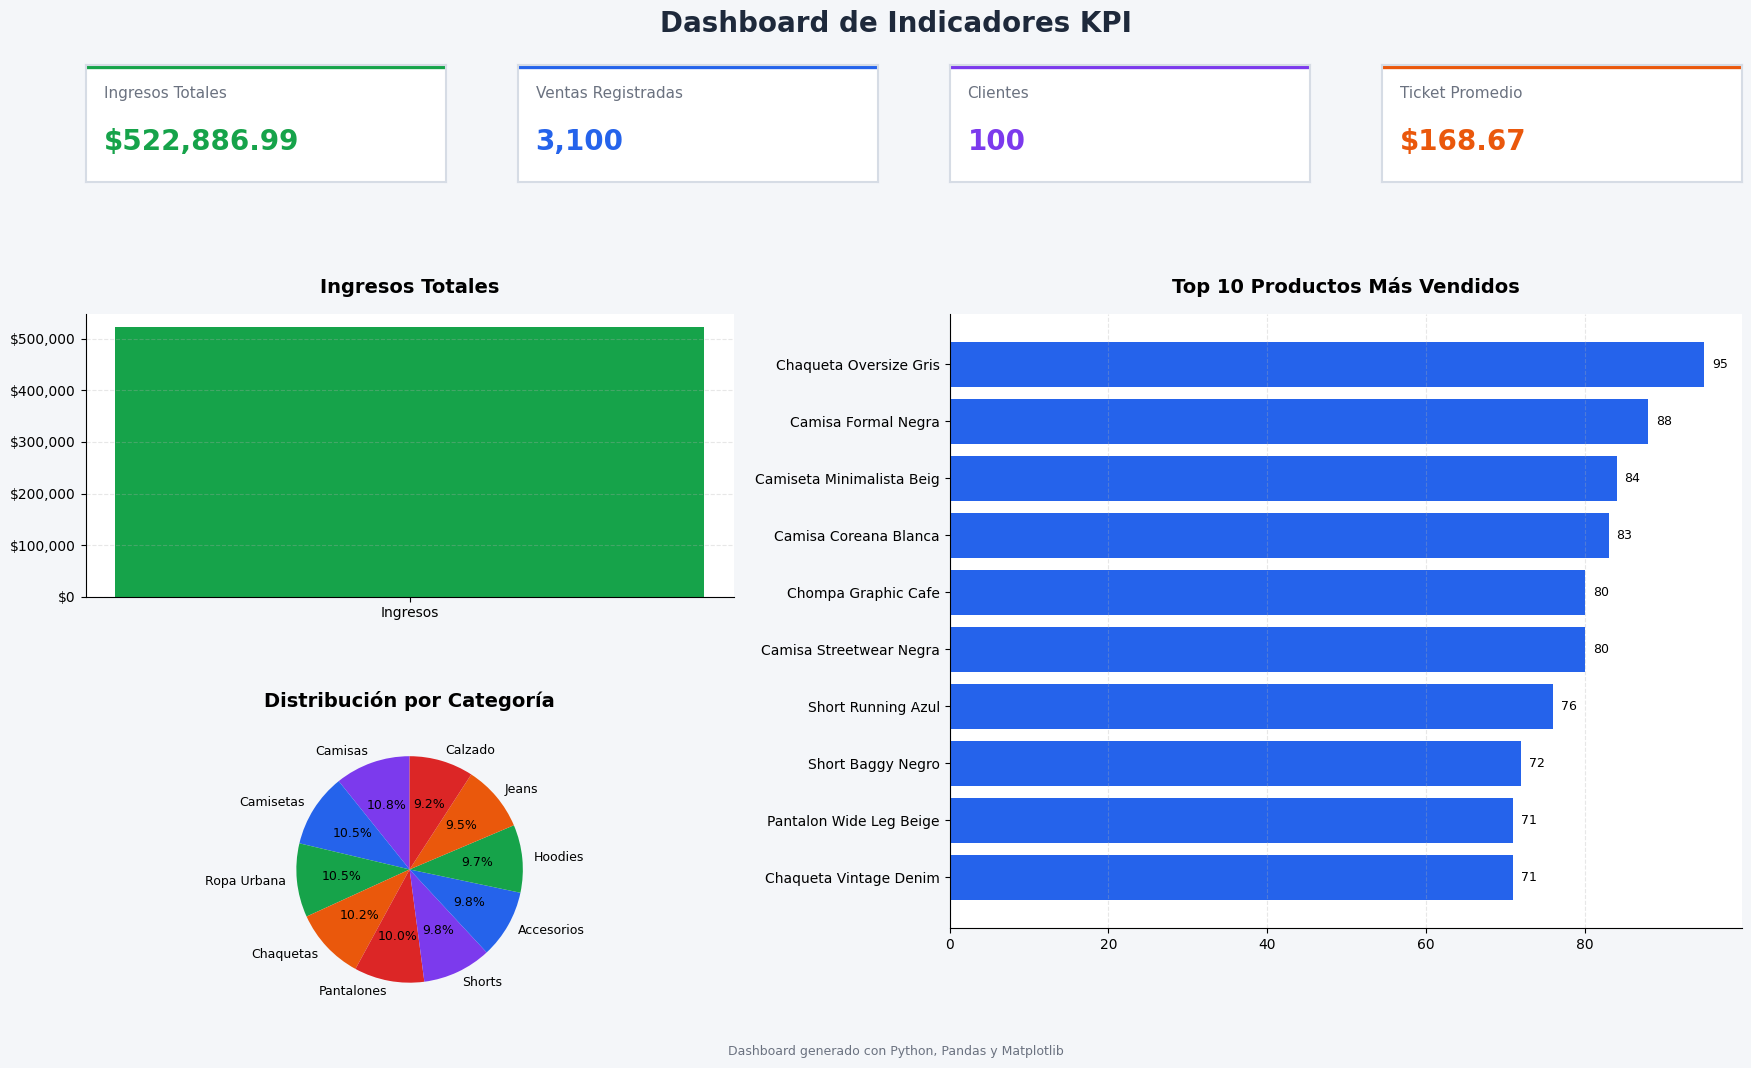


Dashboard generado correctamente


In [12]:
# ════════════════════════════════════════════════════════════════
# DASHBOARD KPI — NUEVO DISEÑO PROFESIONAL
# ════════════════════════════════════════════════════════════════

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.gridspec import GridSpec

# =========================================================
# CARGA DE DATOS
# =========================================================

ventas = pd.read_csv("ventas3100.csv")
productos = pd.read_csv("productos_200.csv")
usuarios = pd.read_csv("usuarios_100.csv")

print("Archivos cargados correctamente")

# =========================================================
# KPI 1 — INGRESOS TOTALES
# =========================================================

total_ingresos = ventas["total"].sum()

# =========================================================
# KPI 2 — TOP PRODUCTOS
# =========================================================

top_productos = (
    ventas.groupby("id_producto")["cantidad"]
    .sum()
    .reset_index()
    .sort_values(by="cantidad", ascending=False)
    .head(10)
)

top_productos = top_productos.merge(
    productos,
    left_on="id_producto",
    right_on="id",
    how="left"
)

# =========================================================
# KPI 3 — CATEGORÍAS MÁS VENDIDAS
# =========================================================

ventas_productos = ventas.merge(
    productos,
    left_on="id_producto",
    right_on="id"
)

categorias = (
    ventas_productos.groupby("categoria")["cantidad"]
    .sum()
    .sort_values(ascending=False)
)

# =========================================================
# MÉTRICAS GENERALES
# =========================================================

cantidad_ventas = len(ventas)
cantidad_clientes = len(usuarios)
ticket_promedio = ventas["total"].mean()

# =========================================================
# COLORES
# =========================================================

COLOR_FONDO = "#F4F6F9"
COLOR_PANEL = "#FFFFFF"
COLOR_BORDE = "#D6DCE5"

AZUL = "#2563EB"
VERDE = "#16A34A"
ROJO = "#DC2626"
NARANJA = "#EA580C"
MORADO = "#7C3AED"
GRIS = "#6B7280"

# =========================================================
# CREAR FIGURA
# =========================================================

fig = plt.figure(
    figsize=(18, 11),
    facecolor=COLOR_FONDO
)

fig.suptitle(
    "Dashboard de Indicadores KPI",
    fontsize=20,
    fontweight="bold",
    color="#1E293B",
    y=0.97
)

# NUEVA ESTRUCTURA
gs = GridSpec(
    12,
    12,
    figure=fig,
    wspace=1.0,
    hspace=1.4
)

# =========================================================
# TARJETAS KPI
# =========================================================

tarjetas = [
    ("Ingresos Totales", f"${total_ingresos:,.2f}", VERDE),
    ("Ventas Registradas", f"{cantidad_ventas:,}", AZUL),
    ("Clientes", f"{cantidad_clientes:,}", MORADO),
    ("Ticket Promedio", f"${ticket_promedio:,.2f}", NARANJA),
]

for i, (titulo, valor, color) in enumerate(tarjetas):

    ax = fig.add_subplot(gs[0:2, i*3:(i+1)*3])

    ax.set_facecolor(COLOR_PANEL)

    for spine in ax.spines.values():
        spine.set_color(COLOR_BORDE)
        spine.set_linewidth(1.5)

    ax.set_xticks([])
    ax.set_yticks([])

    ax.text(
        0.05,
        0.72,
        titulo,
        fontsize=11,
        color=GRIS,
        transform=ax.transAxes
    )

    ax.text(
        0.05,
        0.28,
        valor,
        fontsize=20,
        fontweight="bold",
        color=color,
        transform=ax.transAxes
    )

    ax.axhline(
        y=1,
        color=color,
        linewidth=6
    )

# =========================================================
# GRÁFICO 1 — INGRESOS
# =========================================================

ax1 = fig.add_subplot(gs[3:7, 0:5])

ax1.set_facecolor(COLOR_PANEL)

ax1.bar(
    ["Ingresos"],
    [total_ingresos],
    color=VERDE,
    width=0.5
)

ax1.set_title(
    "Ingresos Totales",
    fontsize=14,
    fontweight="bold",
    pad=15
)

ax1.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f"${x:,.0f}")
)

ax1.grid(
    axis="y",
    linestyle="--",
    alpha=0.3
)

ax1.spines["top"].set_visible(False)
ax1.spines["right"].set_visible(False)

# =========================================================
# GRÁFICO 2 — TOP PRODUCTOS
# =========================================================

ax2 = fig.add_subplot(gs[3:11, 6:12])

ax2.set_facecolor(COLOR_PANEL)

nombres = [
    nombre[:25]
    for nombre in top_productos["nombre"]
]

bars = ax2.barh(
    nombres[::-1],
    top_productos["cantidad"][::-1],
    color=AZUL
)

ax2.set_title(
    "Top 10 Productos Más Vendidos",
    fontsize=14,
    fontweight="bold",
    pad=15
)

ax2.grid(
    axis="x",
    linestyle="--",
    alpha=0.3
)

ax2.spines["top"].set_visible(False)
ax2.spines["right"].set_visible(False)

# Etiquetas
for bar in bars:

    ancho = bar.get_width()

    ax2.text(
        ancho + 1,
        bar.get_y() + bar.get_height()/2,
        f"{int(ancho)}",
        va="center",
        fontsize=9
    )

# =========================================================
# GRÁFICO 3 — CATEGORÍAS
# =========================================================

ax3 = fig.add_subplot(gs[8:12, 0:5])

ax3.set_facecolor(COLOR_PANEL)

categorias.plot(
    kind="pie",
    autopct="%1.1f%%",
    ax=ax3,
    startangle=90,
    colors=[
        MORADO,
        AZUL,
        VERDE,
        NARANJA,
        ROJO
    ],
    textprops={
        "fontsize": 9
    }
)

ax3.set_ylabel("")

ax3.set_title(
    "Distribución por Categoría",
    fontsize=14,
    fontweight="bold",
    pad=15
)

# =========================================================
# FOOTER
# =========================================================

fig.text(
    0.5,
    0.02,
    "Dashboard generado con Python, Pandas y Matplotlib",
    ha="center",
    fontsize=9,
    color=GRIS
)

# =========================================================
# AJUSTE FINAL
# =========================================================

plt.subplots_adjust(
    left=0.05,
    right=0.97,
    top=0.92,
    bottom=0.06
)

# =========================================================
# GUARDAR
# =========================================================

plt.savefig(
    "dashboard_profesional.png",
    dpi=150,
    bbox_inches="tight",
    facecolor=COLOR_FONDO
)

plt.show()

print("\nDashboard generado correctamente")

# 4: Validación de Atributos de Información e Interpretación Gerencial
# 4.1 Matriz de Atributos de Valor

## Simplicidad
Los gráficos generados presentan únicamente la información relevante para la toma de decisiones, evitando sobrecarga visual y facilitando la interpretación de los KPIs.

---

## Oportunidad (Timeliness)
El sistema procesa automáticamente miles de registros almacenados en los archivos CSV, permitiendo obtener resultados rápidos y oportunos para la gerencia.

---

## Accesibilidad
Las visualizaciones utilizan gráficos simples y etiquetas claras, permitiendo que usuarios no técnicos comprendan fácilmente el comportamiento del negocio.

# 4.2 Interpretación Gerencial

## KPI 1 — Total de Ingresos

Si el indicador de ingresos presenta una disminución significativa, la gerencia debe implementar promociones, campañas publicitarias o descuentos para aumentar las ventas y mejorar la rentabilidad del negocio.

---

## KPI 2 — Producto Más Vendido

Si un producto presenta una demanda elevada, la empresa debe incrementar el stock disponible y priorizar su comercialización para evitar pérdidas por falta de inventario.

---

## KPI 3 — Categoría Más Vendida

Si una categoría domina las ventas del negocio, la gerencia debe enfocar inversiones, publicidad y estrategias comerciales en esa línea de productos para maximizar beneficios.